In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/snmp_cleaned.csv')

X = df.drop(columns=['class', 'class_encoded'])
y = df['class_encoded']

print(f"Shape: {X.shape}")
print(f"Classes: {y.value_counts()}")

Shape: (40262, 22)
Classes: class_encoded
0    36902
4      484
1      480
2      480
3      480
6      480
7      480
5      476
Name: count, dtype: int64


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify garante proporção igual em treino/teste
)

print(f"Treino: {X_train.shape}")
print(f"Teste:  {X_test.shape}")

Treino: (32209, 22)
Teste:  (8053, 22)


In [3]:
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',  # corrige o desbalanceamento automaticamente
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("✅ Modelo treinado!")

✅ Modelo treinado!


In [4]:
y_pred = model.predict(X_test)

classes = ['normal','sign_a','sign_b','sign_c','sign_d','sign_e','sign_f','sign_g']
print(classification_report(y_test, y_pred, target_names=classes))

              precision    recall  f1-score   support

      normal       1.00      1.00      1.00      7381
      sign_a       1.00      1.00      1.00        96
      sign_b       1.00      1.00      1.00        96
      sign_c       1.00      0.99      0.99        96
      sign_d       1.00      0.99      0.99        97
      sign_e       1.00      1.00      1.00        95
      sign_f       1.00      1.00      1.00        96
      sign_g       1.00      1.00      1.00        96

    accuracy                           1.00      8053
   macro avg       1.00      1.00      1.00      8053
weighted avg       1.00      1.00      1.00      8053



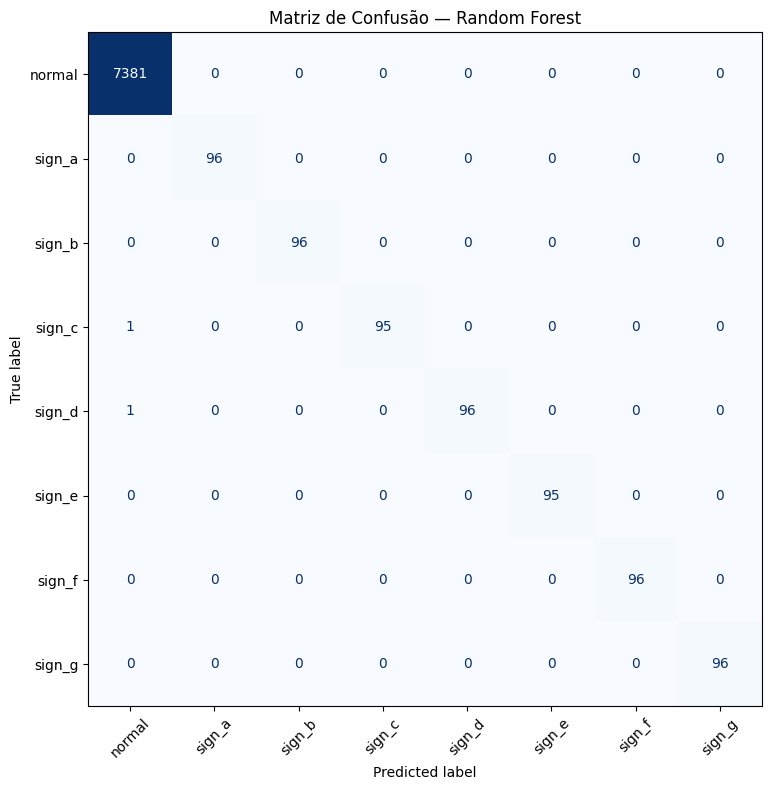

In [5]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Matriz de Confusão — Random Forest')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/figures/matriz_confusao.png', dpi=150)
plt.show()